# Step 4 — 慢機台下鑽

**目標**：找出持續性慢的 device（非偶發異常）

**資料範圍**：全部訂單，僅排除 user contention。
原因：Step 2 的 per-device IQR 可能把 slow device 的正常高值標為 device_timeout，
排除後會壓低該 device 的 median，導致 slow device 被漏掉。
（Step 3 排除 system anomaly 是正確的 — 目的不同：Step 3 看正常運作的瓶頸，Step 4 看 device 完整表現）

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
order_flags = pd.read_csv('../data/order_flags.csv')
df = df.merge(order_flags, on='order_id')

# Slow device 分析用全部訂單（只排除 user contention）
# 原因：per-device IQR 可能把 slow device 的正常高值標為 anomaly，
#       排除後會壓低該 device 的 median，導致 slow device 被漏掉
normal = df[~df['is_user_anomaly']].copy()
n_sys_anomaly = df['is_system_anomaly'].sum()
print(f"All orders (excl. user contention): {len(normal):,}")
print(f"  (includes {n_sys_anomaly:,} system anomaly orders to avoid bias on slow device detection)")


All orders (excl. user contention): 29,999
  (includes 325 system anomaly orders to avoid bias on slow device detection)


## Device Ranking + Gap Detection

In [3]:
device_perf = normal.groupby('device_id').agg(
    device_dur_median=('device_duration_avg_seconds', 'median'),
    device_dur_mean=('device_duration_avg_seconds', 'mean'),
    device_dur_p95=('device_duration_avg_seconds', lambda x: x.quantile(0.95)),
    order_count=('order_id', 'count'),
).reset_index()

loc_info = df.groupby('device_id').agg(
    loc_1=('loc_1', 'first'), loc_2=('loc_2', 'first'),
    system_name=('system_name', 'first'), device_mode_name=('device_mode_name', 'first'),
).reset_index()
device_perf = device_perf.merge(loc_info, on='device_id')

# Gap detection
sorted_perf = device_perf.sort_values('device_dur_median', ascending=False).reset_index(drop=True)

if len(sorted_perf) < 2:
    print("⚠️  不足 2 台 device，無法做 gap detection")
    slow_devices = pd.DataFrame()
    method = "skipped (< 2 devices)"
    n_slow = 0
    slow_ids = set()
else:
    sorted_perf['gap_to_next'] = sorted_perf['device_dur_median'].diff(-1).abs()
    max_gap_idx = sorted_perf['gap_to_next'].idxmax()
    gap_value = sorted_perf.loc[max_gap_idx, 'gap_to_next']
    next_value = sorted_perf.loc[max_gap_idx + 1, 'device_dur_median'] if max_gap_idx + 1 < len(sorted_perf) else 0
    gap_ratio = gap_value / next_value if next_value > 0 else float('inf')

    if gap_ratio >= GAP_MIN_RATIO:
        slow_devices = sorted_perf.loc[:max_gap_idx]
        method = f"gap detection (gap={gap_value:.1f}s, ratio={gap_ratio:.1f}x)"
    else:
        global_p99 = device_perf['device_dur_median'].quantile(0.99)
        slow_devices = device_perf[device_perf['device_dur_median'] > global_p99]
        method = f"fallback: > global P99 ({global_p99:.1f}s)"

n_slow = len(slow_devices)
slow_ids = set(slow_devices['device_id'])

print(f"Method: {method}")
print(f"Slow devices: {n_slow}")
if n_slow > 0:
    print(f"\n{slow_devices[['device_id','device_dur_median','device_dur_p95','order_count','loc_1','system_name']].to_string(index=False)}")
else:
    print("\nℹ️  沒有明顯的慢機台，所有 device 效能差異不大")


Method: fallback: > global P99 (7.8s)
Slow devices: 20

device_id  device_dur_median  device_dur_p95  order_count loc_1 system_name
 DEV-0013              9.010         14.6700           11 FAB-B   SYS-GAMMA
 DEV-0051              8.535         25.0880           14 FAB-A   SYS-GAMMA
 DEV-0061              8.955         12.9795           18 FAB-C   SYS-ALPHA
 DEV-0065              9.030         24.5700           21 FAB-A    SYS-BETA
 DEV-0228              9.375         15.9120           12 FAB-B   SYS-ALPHA
 DEV-0407              8.480         16.6420           18 FAB-C   SYS-GAMMA
 DEV-0451              9.960         17.0425           16 FAB-B   SYS-ALPHA
 DEV-0476              8.340         14.9180           13 FAB-B   SYS-ALPHA
 DEV-0563              8.575         16.0530           22 FAB-B    SYS-BETA
 DEV-0569              8.780         11.5565           18 FAB-B   SYS-GAMMA
 DEV-0864              9.460         11.2900           11 FAB-A   SYS-ALPHA
 DEV-1034              9.015    

## 圖表

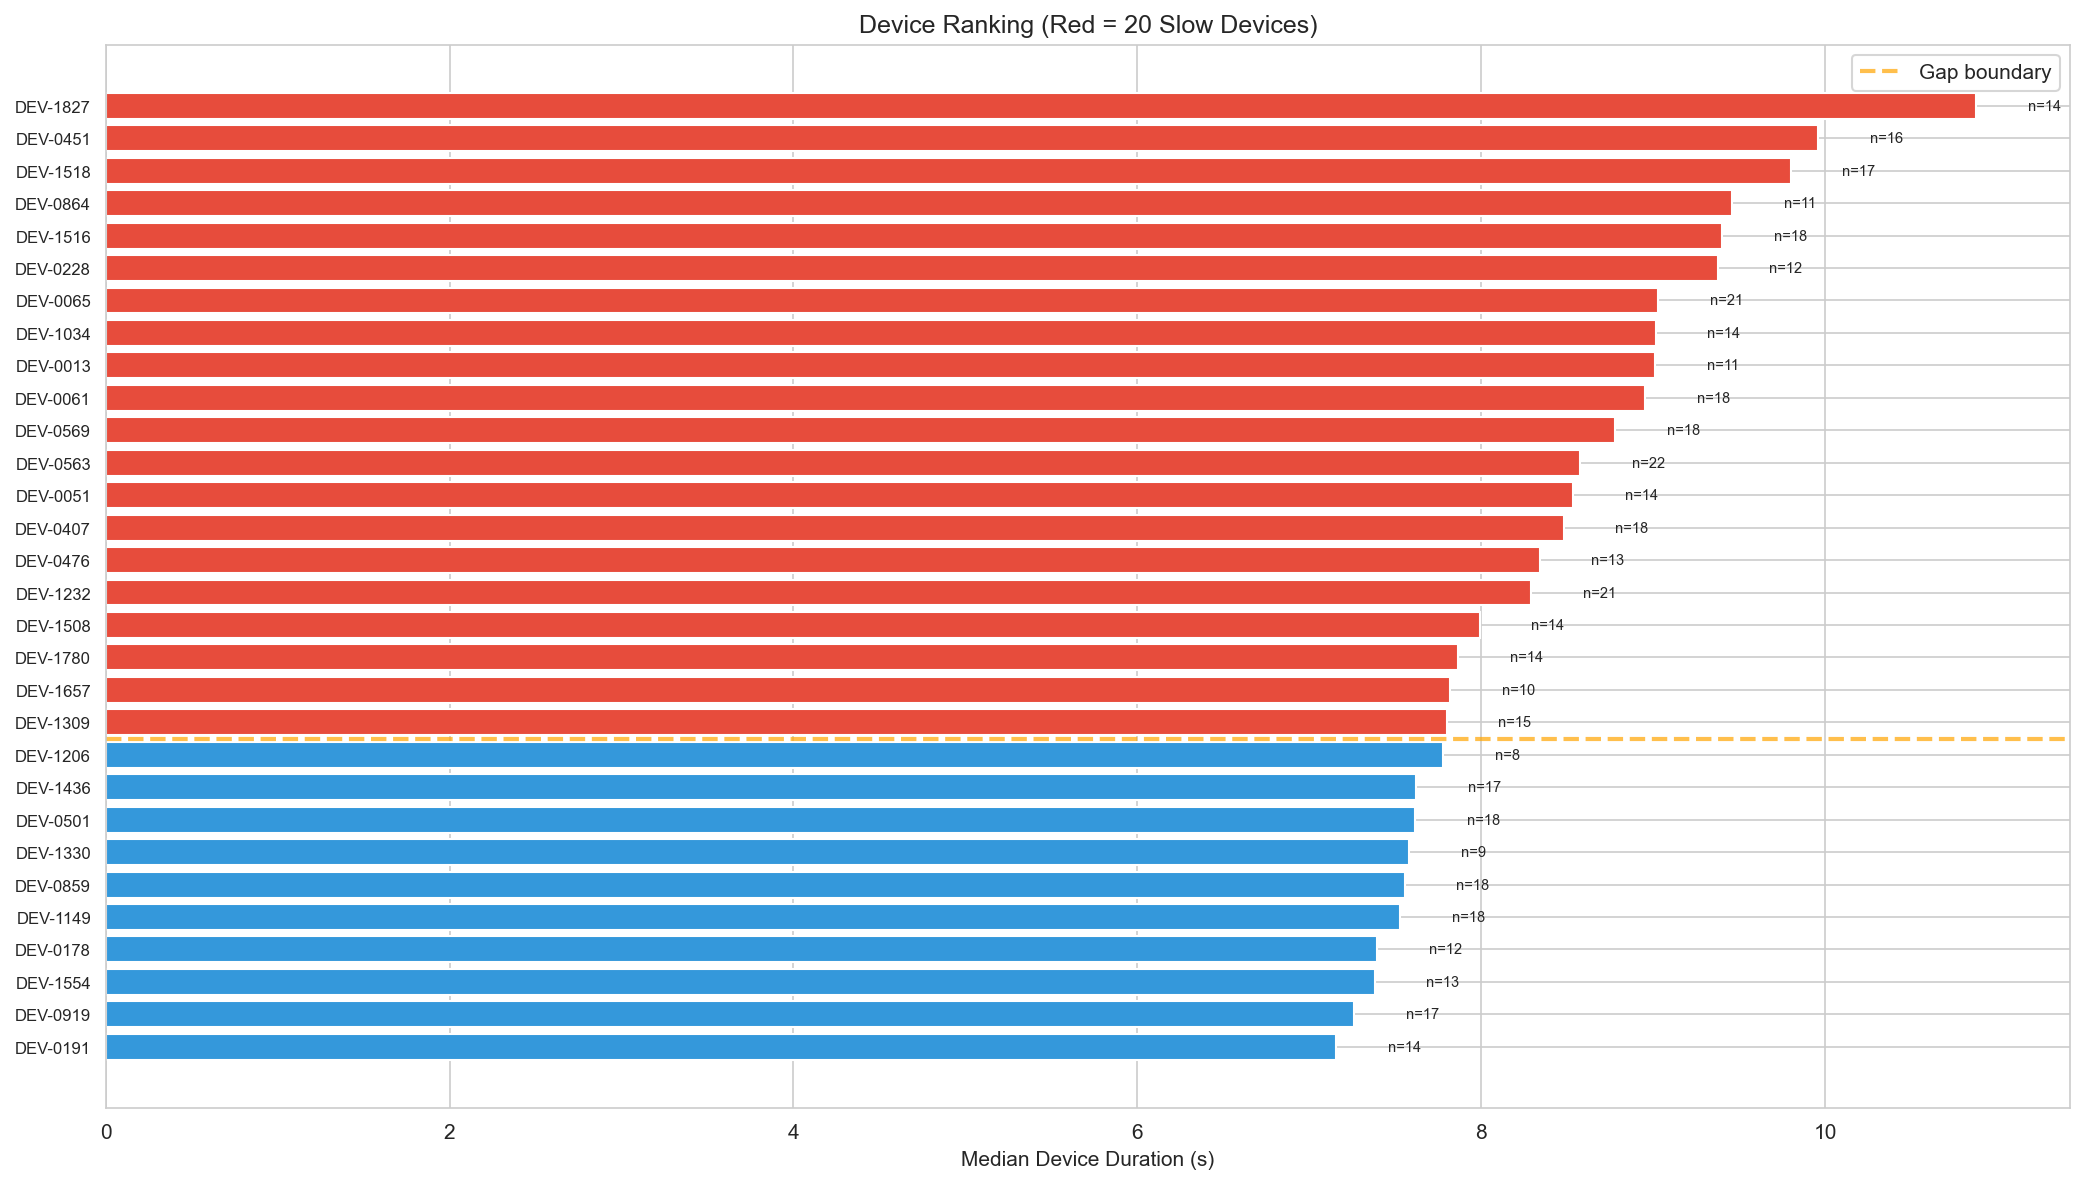

In [4]:
# Device ranking chart
top30 = device_perf.nlargest(30, 'device_dur_median')

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if d in slow_ids else '#3498db' for d in top30['device_id']]
ax.barh(range(len(top30)), top30['device_dur_median'].values, color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['device_id'].values, fontsize=8)
ax.set_title(f'Device Ranking (Red = {n_slow} Slow Devices)')
ax.set_xlabel('Median Device Duration (s)')
ax.invert_yaxis()
if n_slow > 0 and n_slow < 30:
    ax.axhline(y=n_slow - 0.5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Gap boundary')
    ax.legend()
for i, (dur, cnt) in enumerate(zip(top30['device_dur_median'], top30['order_count'])):
    ax.text(dur + 0.3, i, f'n={cnt}', va='center', fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_device_ranking.png', dpi=150)
plt.show()


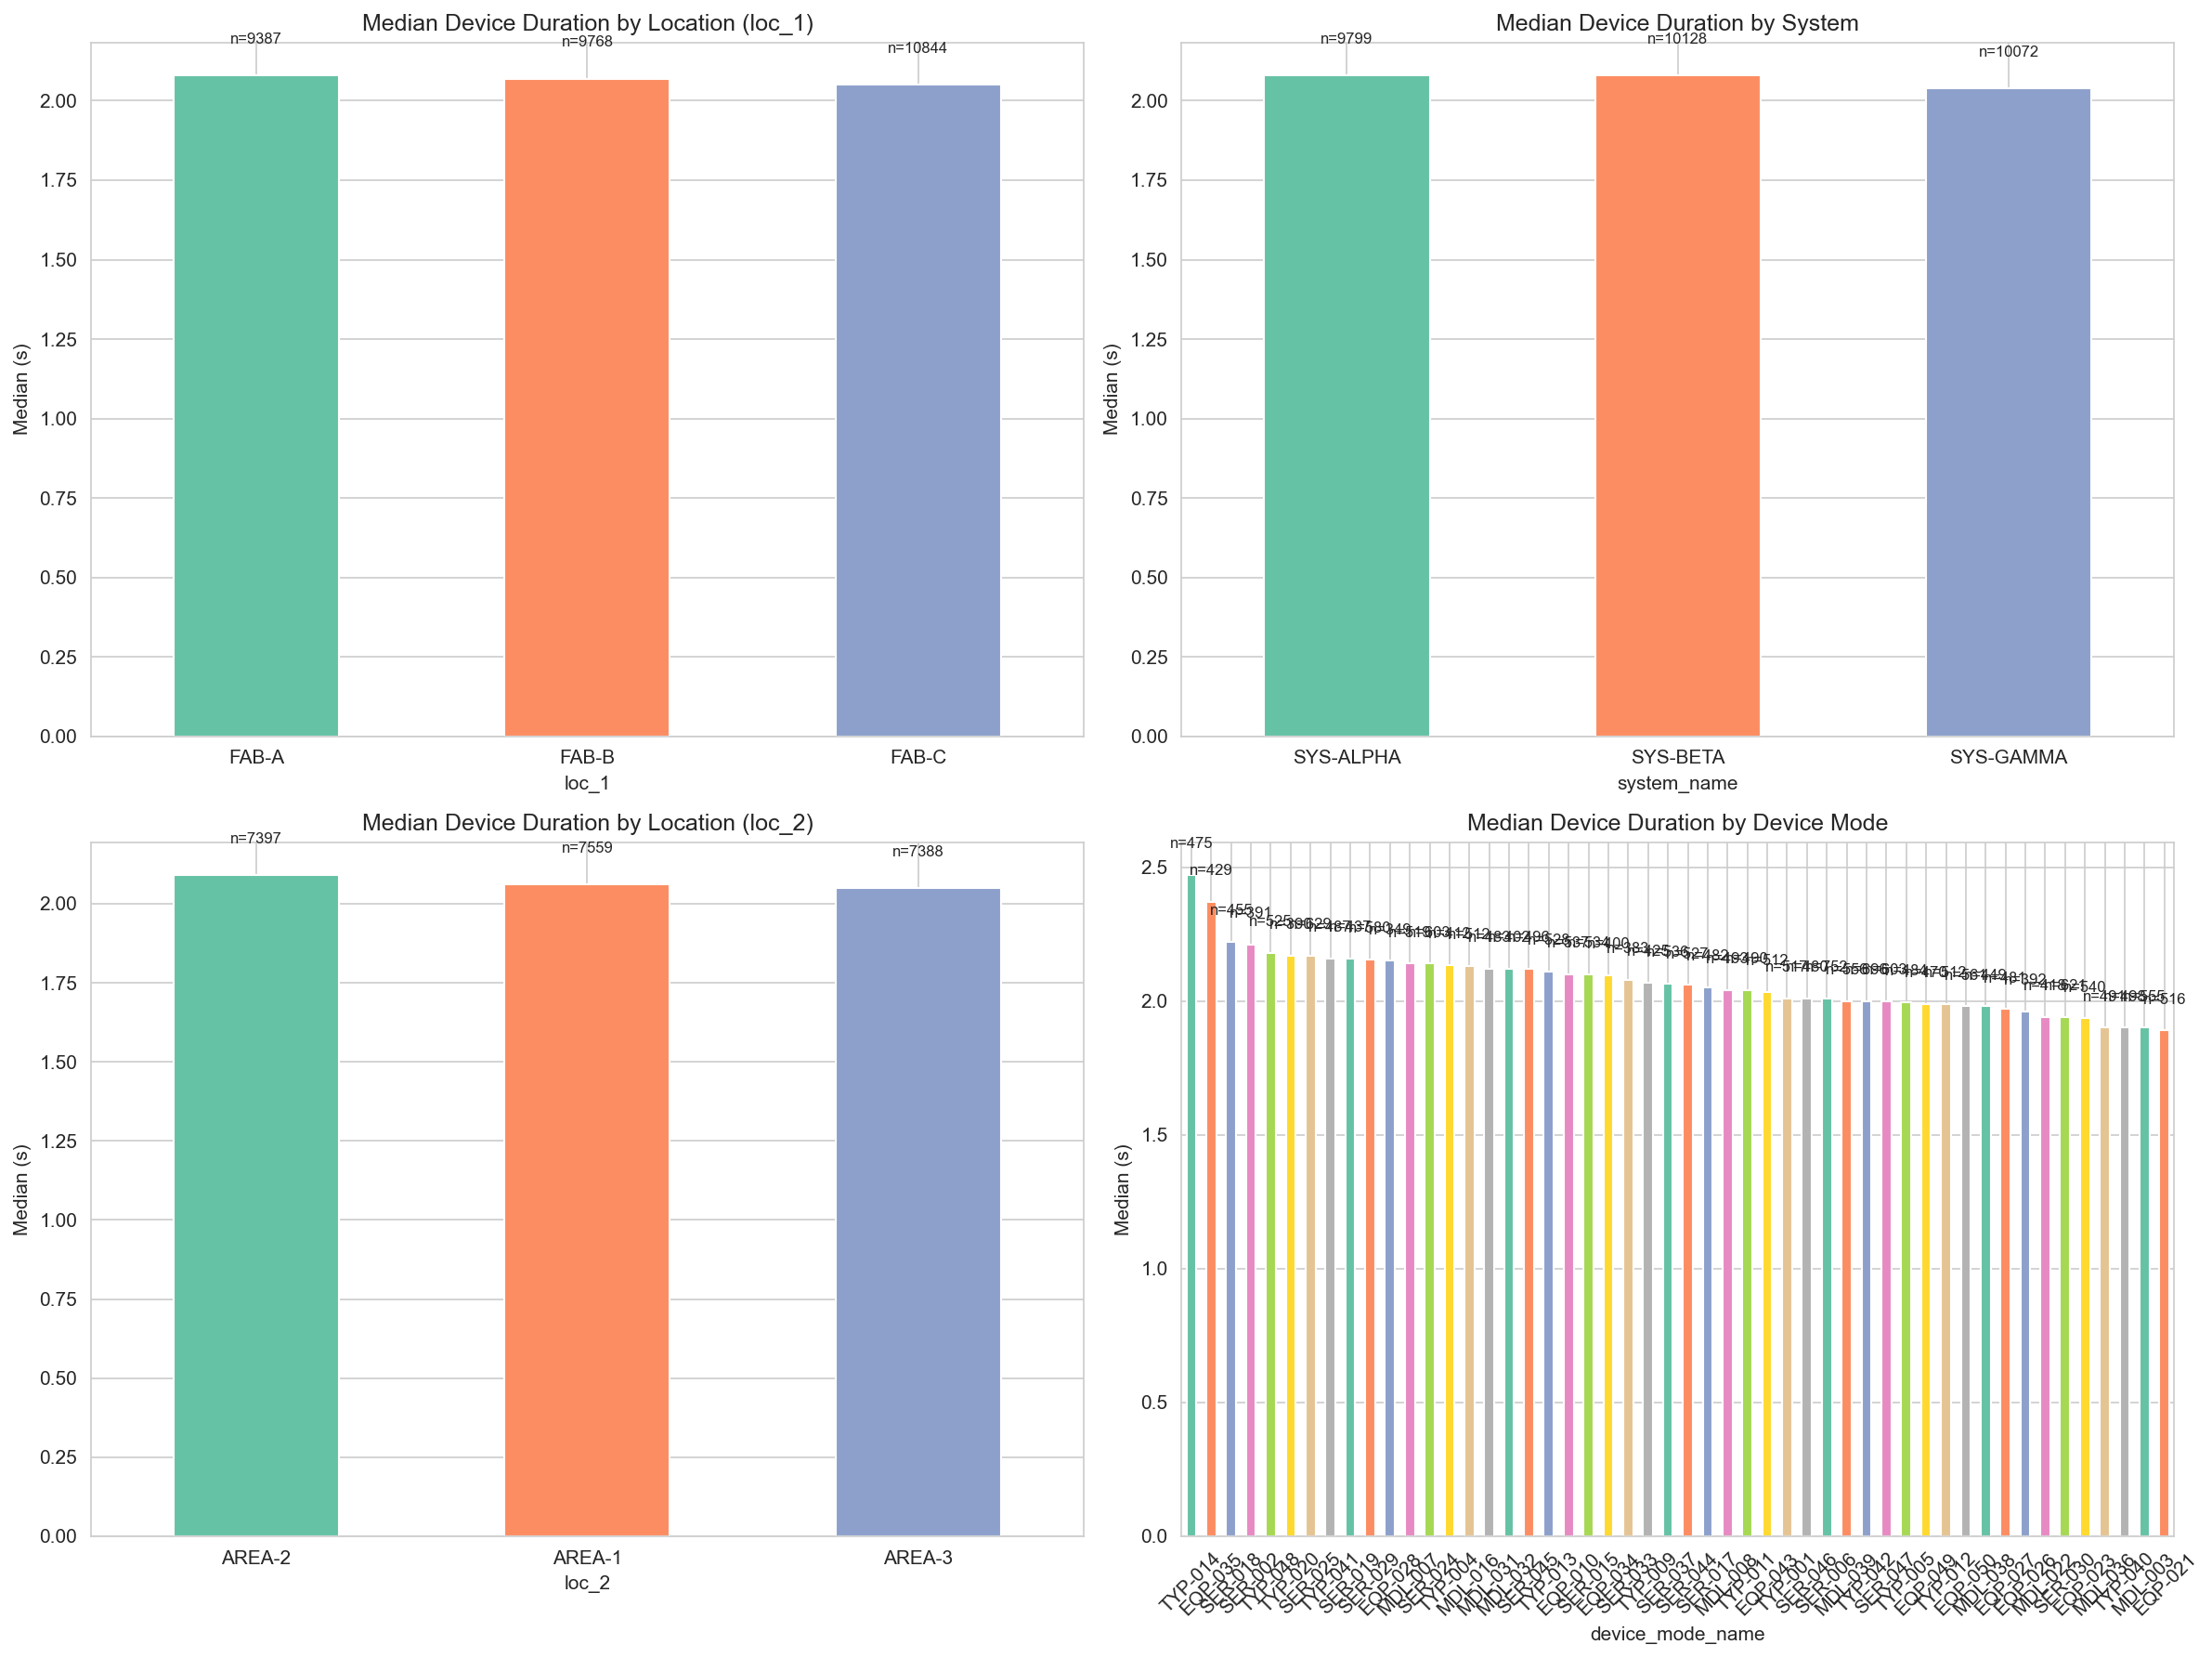

✓ loc_1 無顯著差異 (max/min=1.0x)
✓ system_name 無顯著差異 (max/min=1.0x)


In [5]:
# Facet analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (col, title) in zip(axes.flat, [
    ('loc_1', 'Location (loc_1)'), ('system_name', 'System'),
    ('loc_2', 'Location (loc_2)'), ('device_mode_name', 'Device Mode'),
]):
    data = normal.dropna(subset=[col]) if col in ['loc_2', 'device_mode_name'] else normal
    stats = data.groupby(col)['device_duration_avg_seconds'].agg(['median','count']).sort_values('median', ascending=False)
    stats['median'].plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title(f'Median Device Duration by {title}')
    ax.set_ylabel('Median (s)')
    ax.tick_params(axis='x', rotation=0 if len(stats) < 6 else 45)
    for i, (idx, row) in enumerate(stats.iterrows()):
        ax.text(i, row['median'] + 0.1, f'n={int(row["count"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_facet_analysis.png', dpi=150)
plt.show()

# Data-driven facet conclusion
for facet in ['loc_1', 'system_name']:
    stats = normal.groupby(facet)['device_duration_avg_seconds'].median()
    ratio = stats.max() / stats.min() if stats.min() > 0 else float('inf')
    if ratio > 1.5:
        print(f"⚠️  {facet} 有顯著差異 (max/min={ratio:.1f}x)")
    else:
        print(f"✓ {facet} 無顯著差異 (max/min={ratio:.1f}x)")


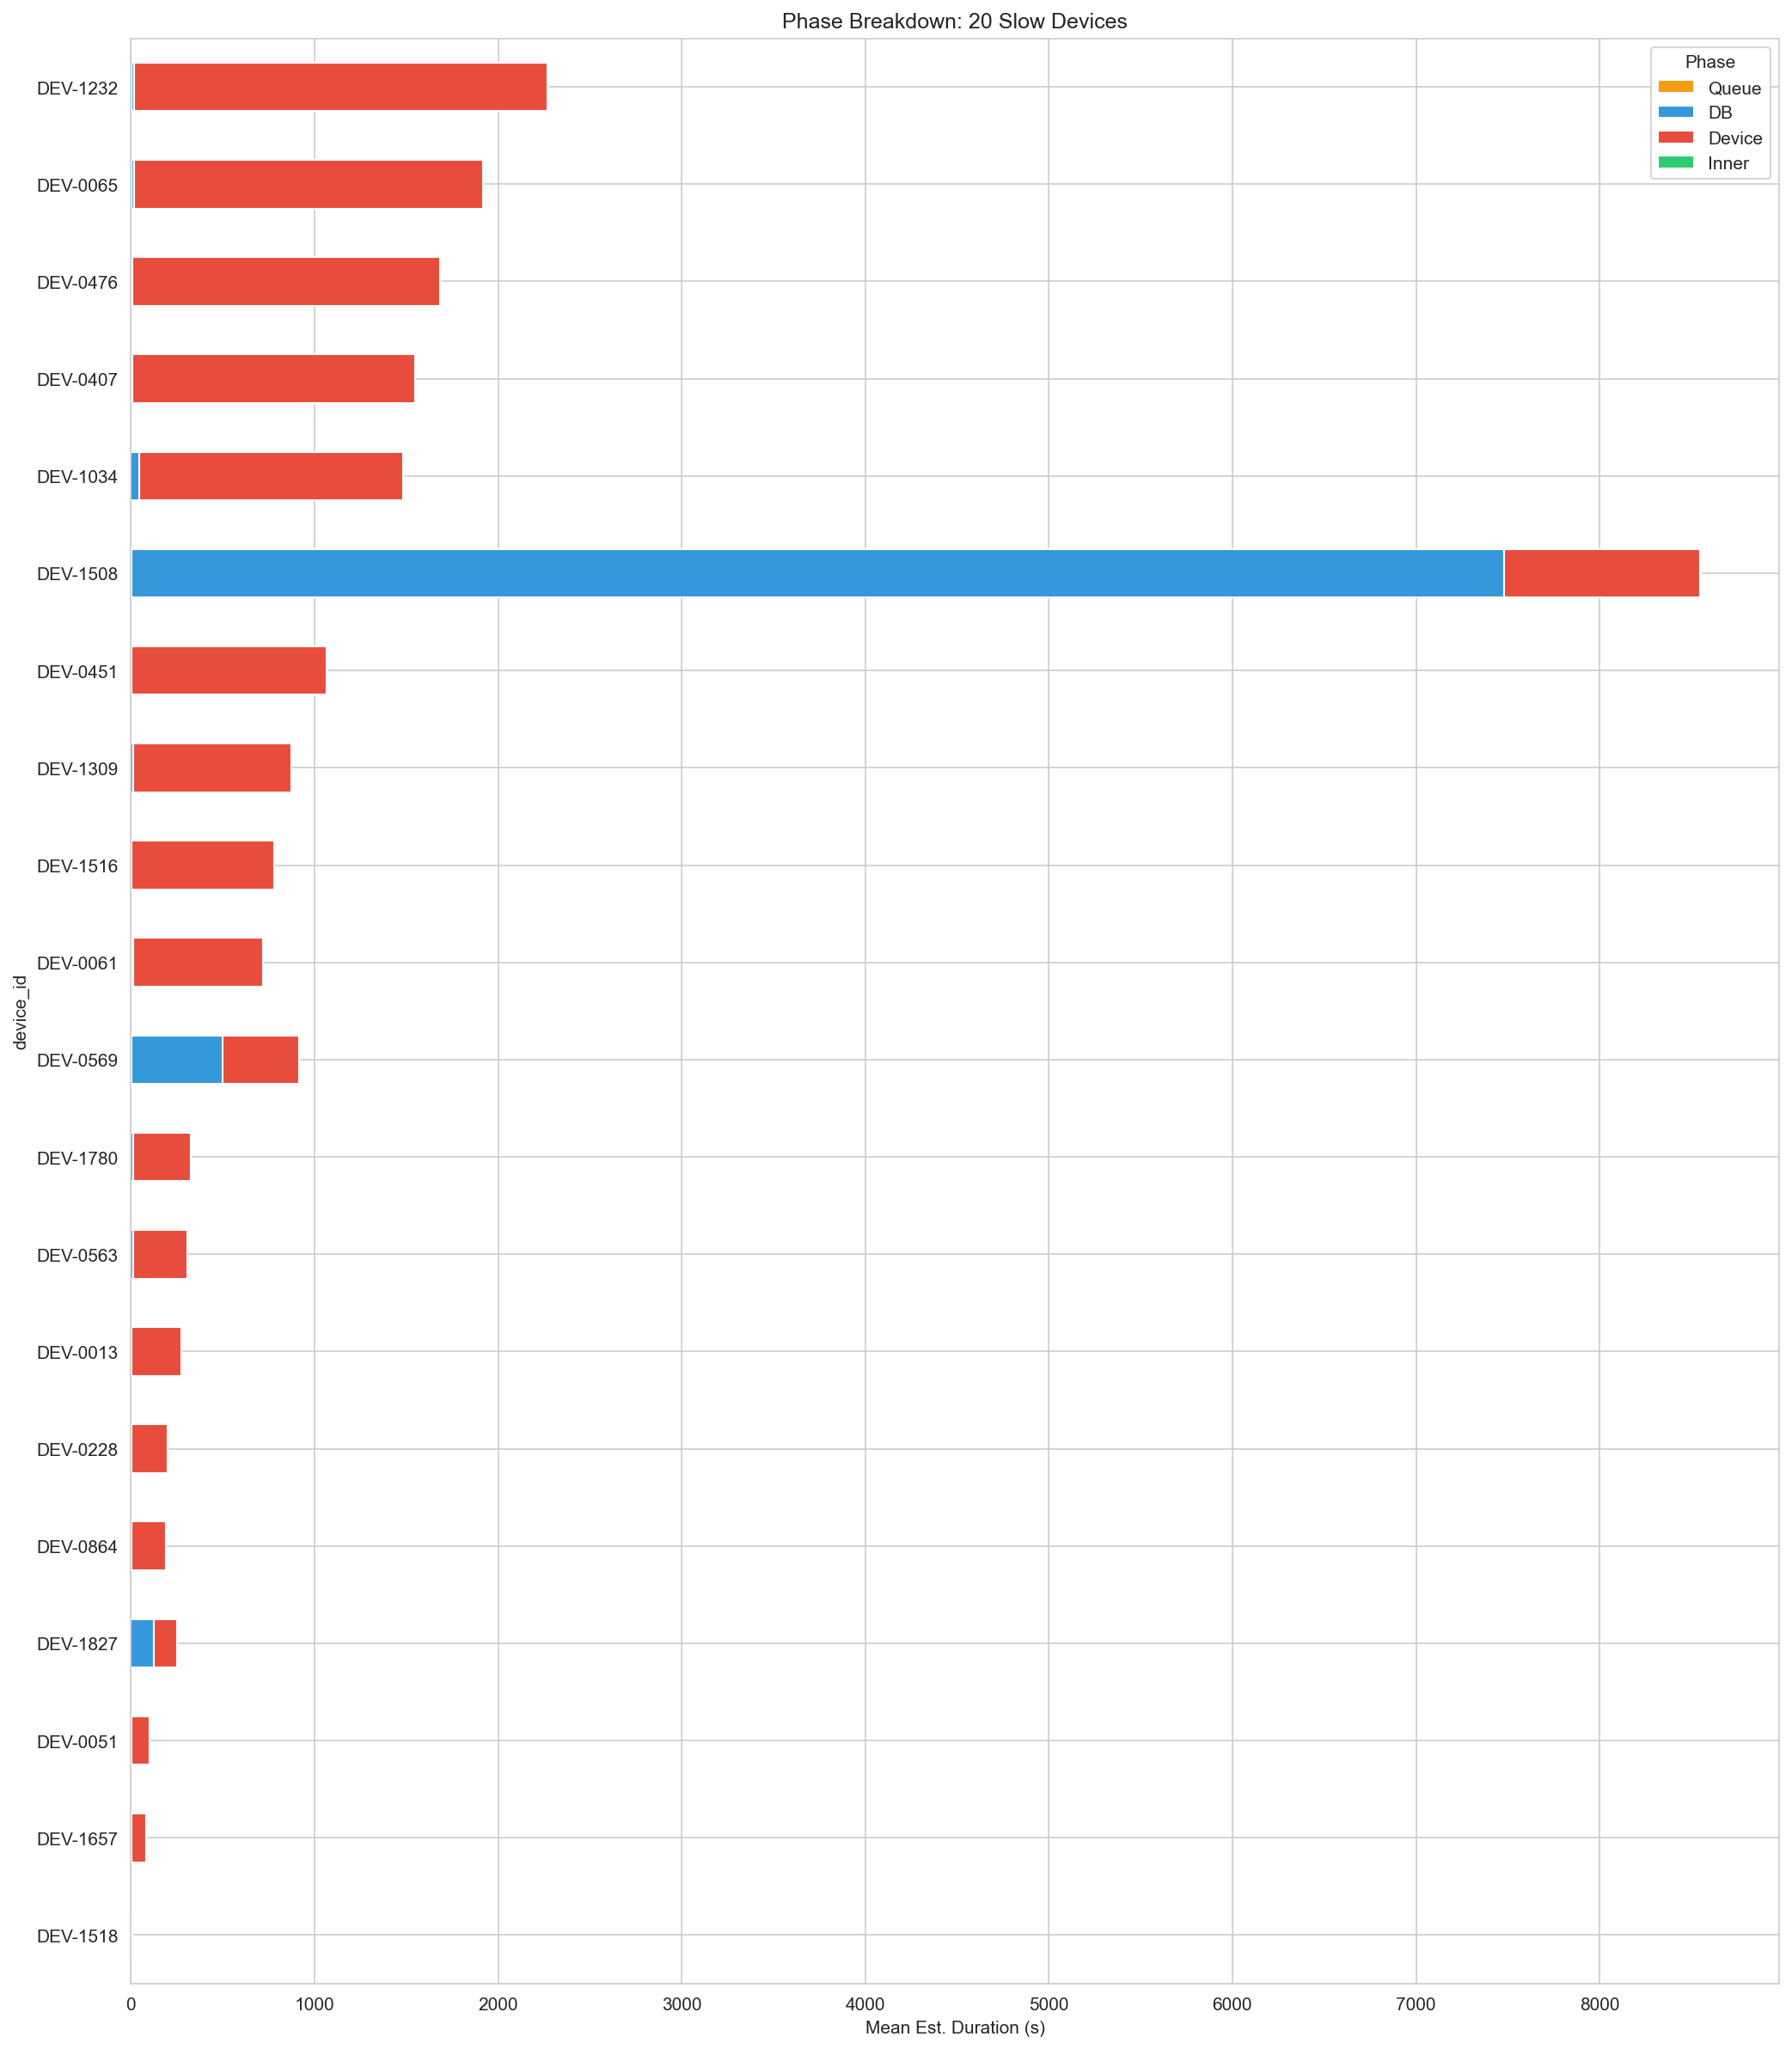

In [6]:
# Slow device phase breakdown (if any)
if n_slow > 0:
    slow_orders = normal[normal['device_id'].isin(slow_ids)].copy()
    slow_orders['est_device'] = slow_orders['device_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_db'] = slow_orders['db_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_inner'] = slow_orders['inner_processing_duration_avg_seconds'] * slow_orders['file_count'] / PARALLELISM
    slow_orders['est_queue'] = slow_orders['queue_duration_seconds']

    fig, ax = plt.subplots(figsize=(14, max(4, n_slow * 0.8)))
    phase_by_dev = slow_orders.groupby('device_id')[['est_queue','est_db','est_device','est_inner']].mean()
    phase_by_dev.columns = ['Queue', 'DB', 'Device', 'Inner']
    phase_by_dev.sort_values('Device', ascending=True).plot(
        kind='barh', stacked=True, ax=ax, color=['#f39c12','#3498db','#e74c3c','#2ecc71'])
    ax.set_title(f'Phase Breakdown: {n_slow} Slow Devices')
    ax.set_xlabel('Mean Est. Duration (s)')
    ax.legend(title='Phase')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'step4_slow_device_breakdown.png', dpi=150)
    plt.show()


## 使用量 × 效能：誰受害最深？

Device 綁定 user，訂單數 = user 使用頻率。
找出「又常用又慢」的 device → 影響最大的 user，優先處理。

High usage threshold: P75 = 17 orders


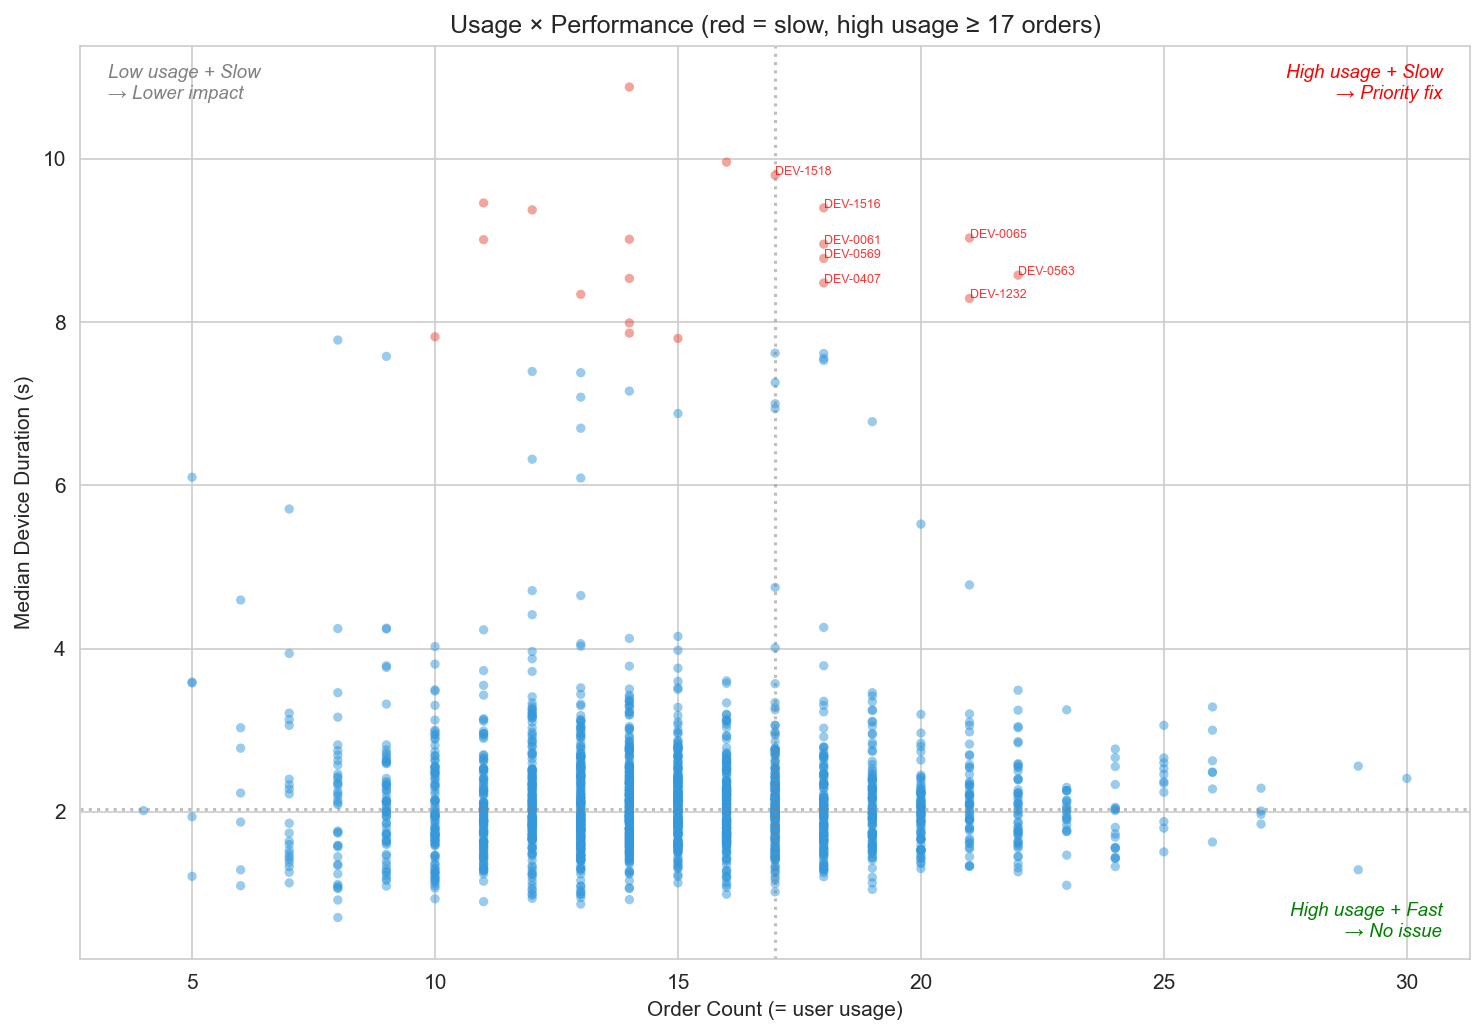

/var/folders/8w/j7kvkq4x17s8f3hvc8qz0gsw0000gq/T/ipykernel_44667/2368524565.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(REPORTS_DIR / 'step4_usage_cross_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/8w/j7kvkq4x17s8f3hvc8qz0gsw0000gq/T/ipykernel_44667/2368524565.py:80: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.savefig(REPORTS_DIR / 'step4_usage_cross_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/8w/j7kvkq4x17s8f3hvc8qz0gsw0000gq/T/ipykernel_44667/2368524565.py:80: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(REPORTS_DIR / 'step4_usage_cross_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from curre

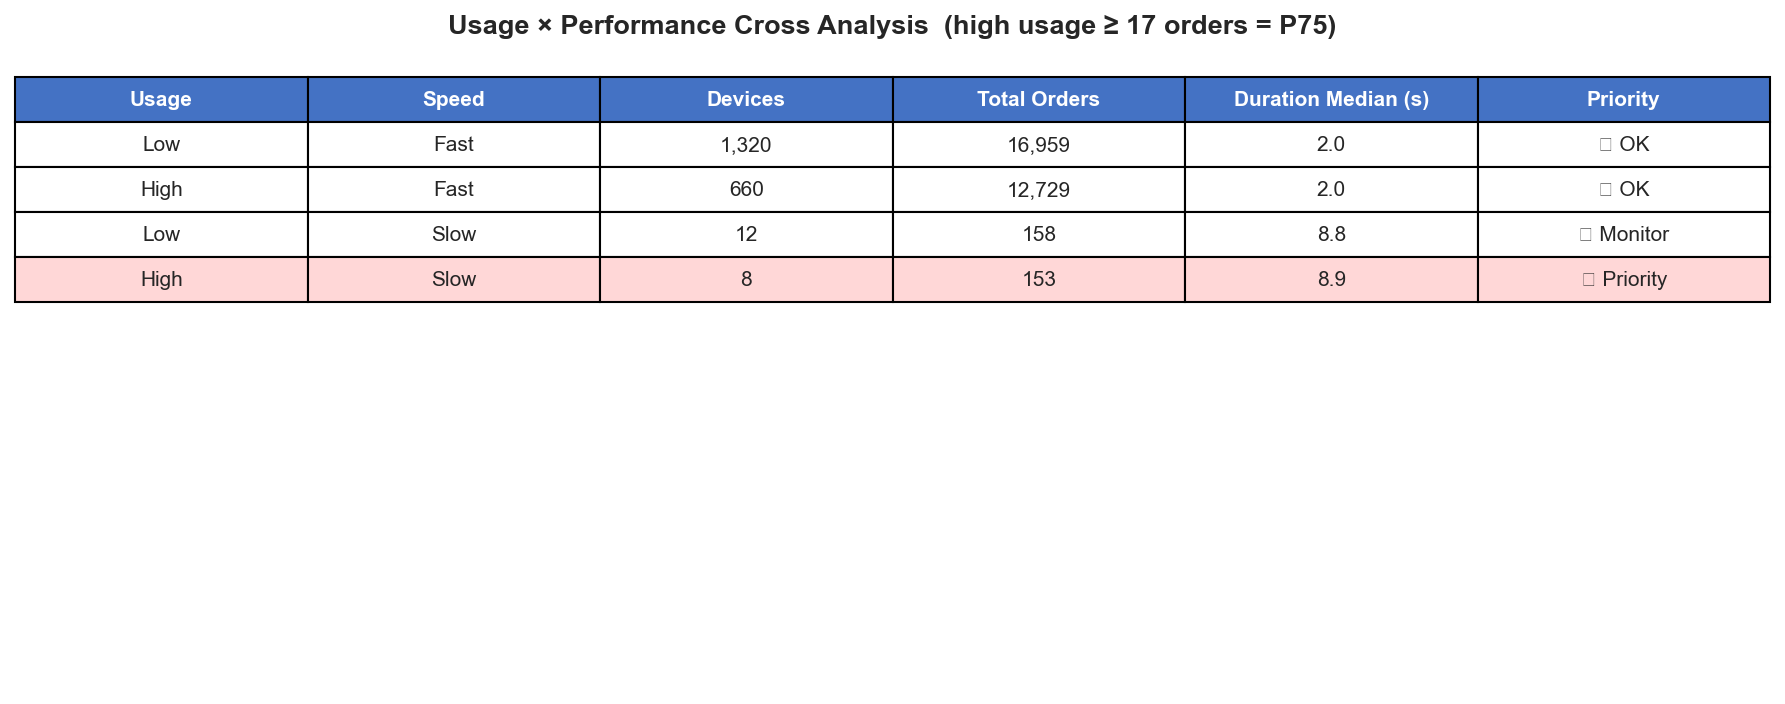

/var/folders/8w/j7kvkq4x17s8f3hvc8qz0gsw0000gq/T/ipykernel_44667/2368524565.py:109: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
/var/folders/8w/j7kvkq4x17s8f3hvc8qz0gsw0000gq/T/ipykernel_44667/2368524565.py:110: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(REPORTS_DIR / 'step4_priority_devices.png', dpi=150, bbox_inches='tight', facecolor='white')


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


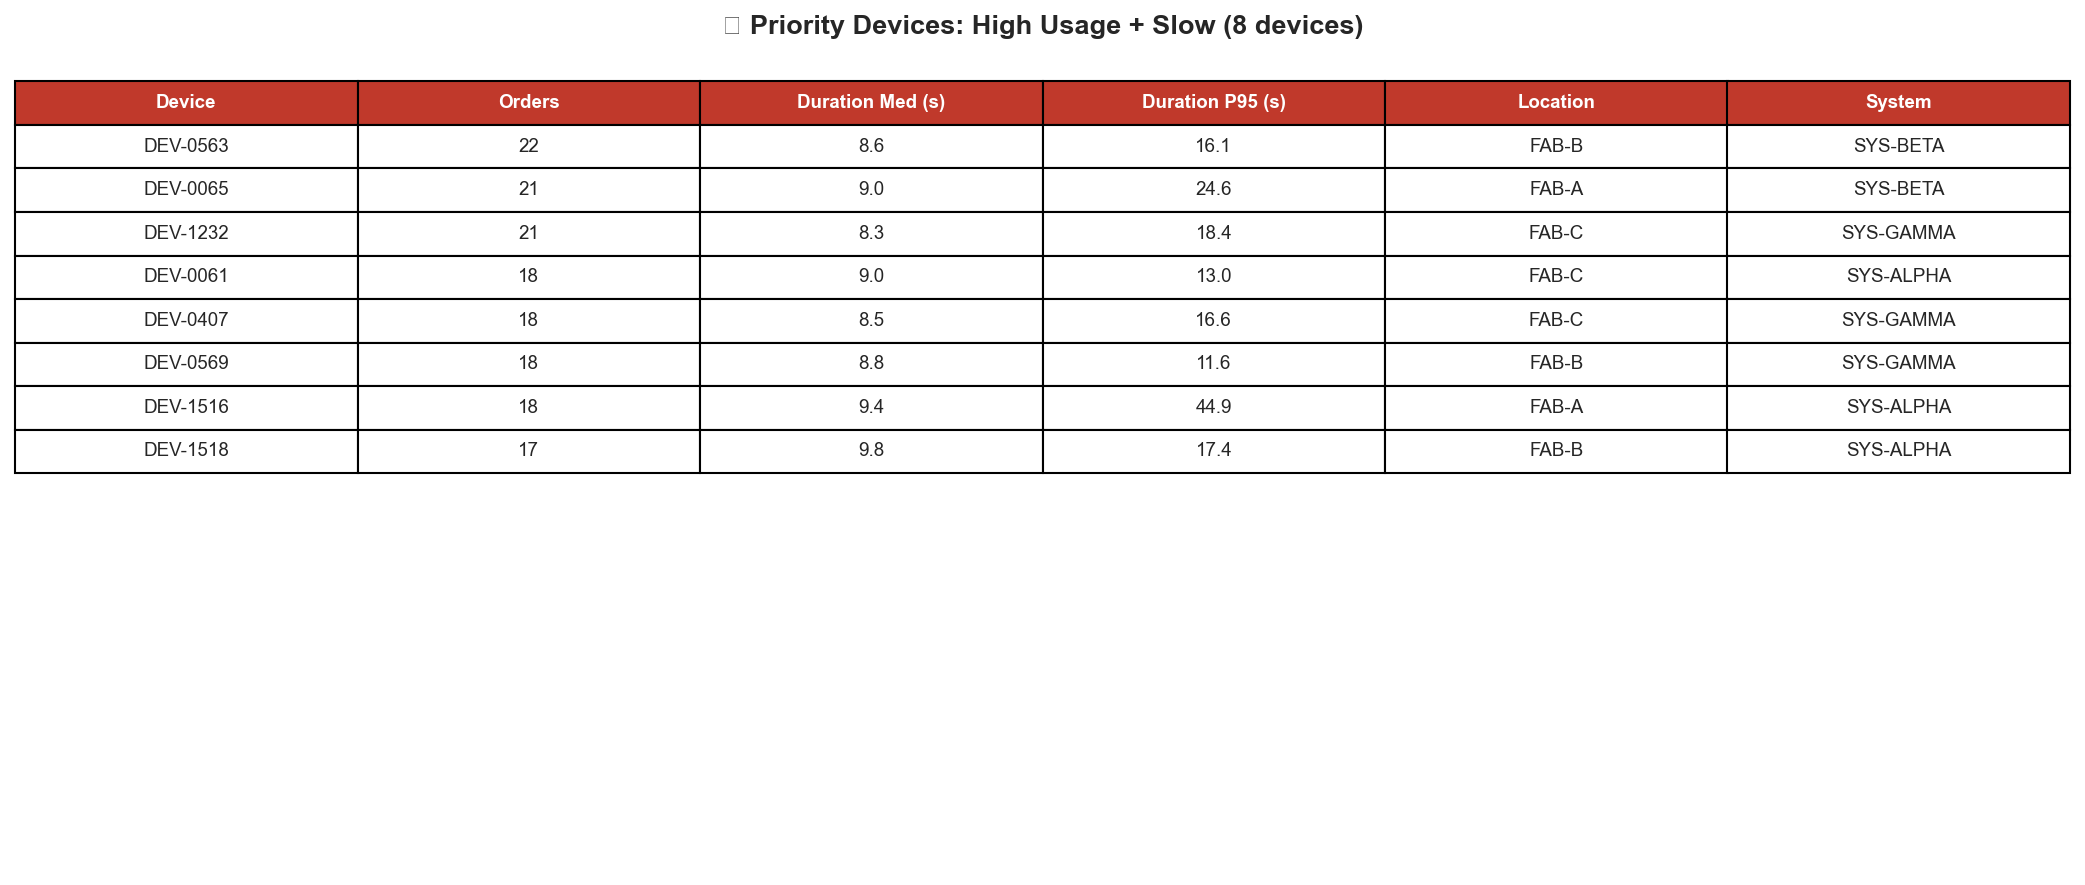


Quadrant summary (high usage ≥ 17 orders = P75):
   Low usage + Fast: 1320 devices, 16959 orders, median=2.0s  ✅ OK
  High usage + Fast:  660 devices, 12729 orders, median=2.0s  ✅ OK
   Low usage + Slow:   12 devices,   158 orders, median=8.8s  🟡 Monitor
  High usage + Slow:    8 devices,   153 orders, median=8.9s  🔴 Priority

🔴 Priority devices (8):
  DEV-0563: 22 orders, median=8.6s, loc=FAB-B/AREA-2, sys=SYS-BETA
  DEV-0065: 21 orders, median=9.0s, loc=FAB-A/AREA-2, sys=SYS-BETA
  DEV-1232: 21 orders, median=8.3s, loc=FAB-C/AREA-1, sys=SYS-GAMMA
  DEV-0061: 18 orders, median=9.0s, loc=FAB-C/AREA-1, sys=SYS-ALPHA
  DEV-0407: 18 orders, median=8.5s, loc=FAB-C/AREA-2, sys=SYS-GAMMA
  DEV-0569: 18 orders, median=8.8s, loc=FAB-B/None, sys=SYS-GAMMA
  DEV-1516: 18 orders, median=9.4s, loc=FAB-A/AREA-2, sys=SYS-ALPHA
  DEV-1518: 17 orders, median=9.8s, loc=FAB-B/None, sys=SYS-ALPHA


In [7]:
# Usage × Performance: which users are most affected?
# device order count = user usage frequency (device 綁定 user)

# --- High usage threshold ---
usage_threshold = device_perf['order_count'].quantile(HIGH_USAGE_PERCENTILE / 100)
print(f"High usage threshold: P{HIGH_USAGE_PERCENTILE} = {usage_threshold:.0f} orders")

# --- Scatter: order count vs device_duration median ---
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if d in slow_ids else '#3498db' for d in device_perf['device_id']]
ax.scatter(device_perf['order_count'], device_perf['device_dur_median'],
           c=colors, alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel('Order Count (= user usage)')
ax.set_ylabel('Median Device Duration (s)')
ax.set_title(f'Usage × Performance (red = slow, high usage ≥ {usage_threshold:.0f} orders)')

# Quadrant lines + labels
ax.axvline(x=usage_threshold, color='gray', linestyle=':', alpha=0.5)
y_mid = device_perf['device_dur_median'].median()
ax.axhline(y=y_mid, color='gray', linestyle=':', alpha=0.5)
ax.text(0.98, 0.98, 'High usage + Slow\n→ Priority fix', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='red', fontstyle='italic')
ax.text(0.02, 0.98, 'Low usage + Slow\n→ Lower impact', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='gray', fontstyle='italic')
ax.text(0.98, 0.02, 'High usage + Fast\n→ No issue', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='green', fontstyle='italic')

# Annotate high-usage + slow devices
high_usage_slow = device_perf[(device_perf['order_count'] >= usage_threshold) &
                               (device_perf['device_id'].isin(slow_ids))]
if len(high_usage_slow) > 0:
    for _, row in high_usage_slow.iterrows():
        ax.annotate(row['device_id'], (row['order_count'], row['device_dur_median']),
                    fontsize=6, alpha=0.8, color='red')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_usage_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cross-analysis: summary table (4 quadrants) ---
device_perf['usage'] = np.where(device_perf['order_count'] >= usage_threshold, 'High', 'Low')
device_perf['speed'] = np.where(device_perf['device_id'].isin(slow_ids), 'Slow', 'Fast')

cross = device_perf.groupby(['usage', 'speed']).agg(
    devices=('device_id', 'count'),
    total_orders=('order_count', 'sum'),
    dur_median=('device_dur_median', 'median'),
).reset_index()
cross['priority'] = cross.apply(
    lambda r: '🔴 Priority' if r['usage'] == 'High' and r['speed'] == 'Slow'
    else '🟡 Monitor' if r['speed'] == 'Slow'
    else '✅ OK', axis=1)
cross = cross.sort_values(['speed', 'usage'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, max(2.5, len(cross) * 0.7 + 2)))
ax.axis('off')
ax.set_title(f'Usage × Performance Cross Analysis  (high usage ≥ {usage_threshold:.0f} orders = P{HIGH_USAGE_PERCENTILE})',
             fontsize=13, fontweight='bold', pad=15)

col_labels = ['Usage', 'Speed', 'Devices', 'Total Orders', 'Duration Median (s)', 'Priority']
cell_text = []
for _, row in cross.iterrows():
    cell_text.append([row['usage'], row['speed'], f"{row['devices']:,}",
                      f"{row['total_orders']:,}", f"{row['dur_median']:.1f}", row['priority']])

tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellLoc='center', loc='upper center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#4472C4')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for r in range(len(cross)):
    if 'Priority' in cell_text[r][-1]:
        for j in range(len(col_labels)):
            tbl[r + 1, j].set_facecolor('#FFD7D7')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_usage_cross_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Detail table: Priority devices (High usage + Slow) ---
if len(high_usage_slow) > 0:
    detail = high_usage_slow.sort_values('order_count', ascending=False)[
        ['device_id', 'order_count', 'device_dur_median', 'device_dur_p95', 'loc_1', 'system_name']
    ].copy()
    detail.columns = ['Device', 'Orders', 'Duration Med (s)', 'Duration P95 (s)', 'Location', 'System']

    fig, ax = plt.subplots(figsize=(14, max(2.5, len(detail) * 0.5 + 2)))
    ax.axis('off')
    ax.set_title(f'🔴 Priority Devices: High Usage + Slow ({len(detail)} devices)',
                 fontsize=13, fontweight='bold', pad=15)

    cell_text = []
    for _, row in detail.iterrows():
        cell_text.append([row['Device'], f"{row['Orders']}", f"{row['Duration Med (s)']:.1f}",
                          f"{row['Duration P95 (s)']:.1f}", row['Location'], row['System']])

    tbl = ax.table(cellText=cell_text, colLabels=detail.columns.tolist(),
                   cellLoc='center', loc='upper center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    for j in range(len(detail.columns)):
        tbl[0, j].set_facecolor('#C0392B')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'step4_priority_devices.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("No high-usage + slow devices found.")

# Print summary
print(f"\nQuadrant summary (high usage ≥ {usage_threshold:.0f} orders = P{HIGH_USAGE_PERCENTILE}):")
for _, row in cross.iterrows():
    print(f"  {row['usage']:>4} usage + {row['speed']:>4}: {row['devices']:>4} devices, "
          f"{row['total_orders']:>5} orders, median={row['dur_median']:.1f}s  {row['priority']}")

print(f"\n🔴 Priority devices ({len(high_usage_slow)}):")
if len(high_usage_slow) > 0:
    for _, row in high_usage_slow.sort_values('order_count', ascending=False).iterrows():
        print(f'  {row["device_id"]}: {row["order_count"]} orders, '
              f'median={row["device_dur_median"]:.1f}s, '
              f'loc={row["loc_1"]}/{row.get("loc_2","")}, sys={row["system_name"]}')
else:
    print('  (none)')

## Device Summary CSV

以 device 為中心，整合 Step 1-4 分析結果，輸出 `data/device_summary.csv`。
每台 device 一行，包含使用量、效能、變異、標籤等。

In [8]:
# === Device Summary CSV ===
# 以 device 為中心，每台 device 一行

device_summary = normal.groupby('device_id').agg(
    order_count=('order_id', 'count'),
    file_count_median=('file_count', 'median'),
    file_count_p95=('file_count', lambda x: x.quantile(0.95)),
    total_dur_median=('total_duration_seconds', 'median'),
    total_dur_p95=('total_duration_seconds', lambda x: x.quantile(0.95)),
    queue_dur_median=('queue_duration_seconds', 'median'),
    device_dur_median=('device_duration_avg_seconds', 'median'),
    device_dur_p95=('device_duration_avg_seconds', lambda x: x.quantile(0.95)),
    device_dur_mean=('device_duration_avg_seconds', 'mean'),
    device_dur_std=('device_duration_avg_seconds', 'std'),
    db_dur_median=('db_duration_avg_seconds', 'median'),
    inner_dur_median=('inner_processing_duration_avg_seconds', 'median'),
).reset_index()

# CV = std / mean（效能變異係數，越高越不穩定）
device_summary['device_dur_cv'] = (device_summary['device_dur_std'] / 
                                    device_summary['device_dur_mean'].replace(0, np.nan)).round(3)

# Round
for col in ['file_count_median', 'file_count_p95']:
    device_summary[col] = device_summary[col].round(0).astype(int)
for col in ['total_dur_median', 'total_dur_p95', 'queue_dur_median',
            'device_dur_median', 'device_dur_p95', 'device_dur_mean', 'device_dur_std',
            'db_dur_median', 'inner_dur_median']:
    device_summary[col] = device_summary[col].round(2)

# Device attributes
loc_info = df.groupby('device_id').agg(
    device_mode_name=('device_mode_name', 'first'),
    loc_1=('loc_1', 'first'),
    loc_2=('loc_2', 'first'),
    system_name=('system_name', 'first'),
).reset_index()
device_summary = device_summary.merge(loc_info, on='device_id')

# File count bin
device_summary['file_count_bin'] = pd.cut(
    device_summary['file_count_median'], bins=FILE_COUNT_BINS, labels=FILE_COUNT_LABELS
).astype(str)

# Labels
device_summary['is_slow_device'] = device_summary['device_id'].isin(slow_ids)
device_summary['is_high_usage'] = device_summary['order_count'] >= usage_threshold
device_summary['priority'] = device_summary.apply(
    lambda r: 'Priority' if r['is_high_usage'] and r['is_slow_device']
    else 'Monitor' if r['is_slow_device']
    else 'OK', axis=1)

# Anomaly / contention counts
anomaly_counts = df.groupby('device_id').agg(
    system_anomaly_count=('is_system_anomaly', 'sum'),
    user_contention_count=('is_user_anomaly', 'sum'),
).reset_index()
device_summary = device_summary.merge(anomaly_counts, on='device_id', how='left')
# 分母用 df 全部訂單數（含 user contention），避免分母偏小
total_per_device = df.groupby('device_id')['order_id'].count().rename('total_orders_all')
device_summary = device_summary.merge(total_per_device, on='device_id', how='left')
device_summary['system_anomaly_rate'] = (
    device_summary['system_anomaly_count'] / device_summary['total_orders_all'] * 100
).round(1)
device_summary = device_summary.drop(columns='total_orders_all')

# Column order
col_order = [
    'device_id', 'device_mode_name', 'loc_1', 'loc_2', 'system_name',
    'order_count', 'file_count_median', 'file_count_p95', 'file_count_bin',
    'total_dur_median', 'total_dur_p95',
    'queue_dur_median',
    'device_dur_median', 'device_dur_p95', 'device_dur_mean', 'device_dur_std', 'device_dur_cv',
    'db_dur_median', 'inner_dur_median',
    'is_slow_device', 'is_high_usage', 'priority',
    'system_anomaly_count', 'system_anomaly_rate', 'user_contention_count',
]
device_summary = device_summary[col_order]

# Sort: Priority first, then by order_count desc
priority_order = {'Priority': 0, 'Monitor': 1, 'OK': 2}
device_summary['_sort'] = device_summary['priority'].map(priority_order)
device_summary = device_summary.sort_values(['_sort', 'order_count'], ascending=[True, False]).drop(columns='_sort')

# Export
device_summary.to_csv('../data/device_summary.csv', index=False)
print(f'Exported: data/device_summary.csv ({len(device_summary):,} devices)')
print(f'\nColumns: {len(device_summary.columns)}')
for col in device_summary.columns:
    print(f'  {col}')
print(f'\nPriority distribution:')
print(device_summary['priority'].value_counts().to_string())
print(f'\nDevice CV stats: P50={device_summary["device_dur_cv"].median():.3f}, '
      f'P95={device_summary["device_dur_cv"].quantile(0.95):.3f}, '
      f'max={device_summary["device_dur_cv"].max():.3f}')
print(f'\nTop 10 by CV (most variable):')
print(device_summary.nlargest(10, 'device_dur_cv')[[
    'device_id', 'order_count', 'device_dur_median', 'device_dur_cv', 'is_slow_device', 'priority'
]].to_string(index=False))


Exported: data/device_summary.csv (2,000 devices)

Columns: 25
  device_id
  device_mode_name
  loc_1
  loc_2
  system_name
  order_count
  file_count_median
  file_count_p95
  file_count_bin
  total_dur_median
  total_dur_p95
  queue_dur_median
  device_dur_median
  device_dur_p95
  device_dur_mean
  device_dur_std
  device_dur_cv
  db_dur_median
  inner_dur_median
  is_slow_device
  is_high_usage
  priority
  system_anomaly_count
  system_anomaly_rate
  user_contention_count

Priority distribution:
priority
OK          1980
Monitor       12
Priority       8

Device CV stats: P50=0.788, P95=1.387, max=4.271

Top 10 by CV (most variable):
device_id  order_count  device_dur_median  device_dur_cv  is_slow_device priority
 DEV-0761           26               3.00          4.271           False       OK
 DEV-0101           22               2.03          4.118           False       OK
 DEV-1161           25               1.51          4.042           False       OK
 DEV-0880           22   

## Summary

## Device 忙碌度 × 效能

設備在忙碌時段是否變慢？

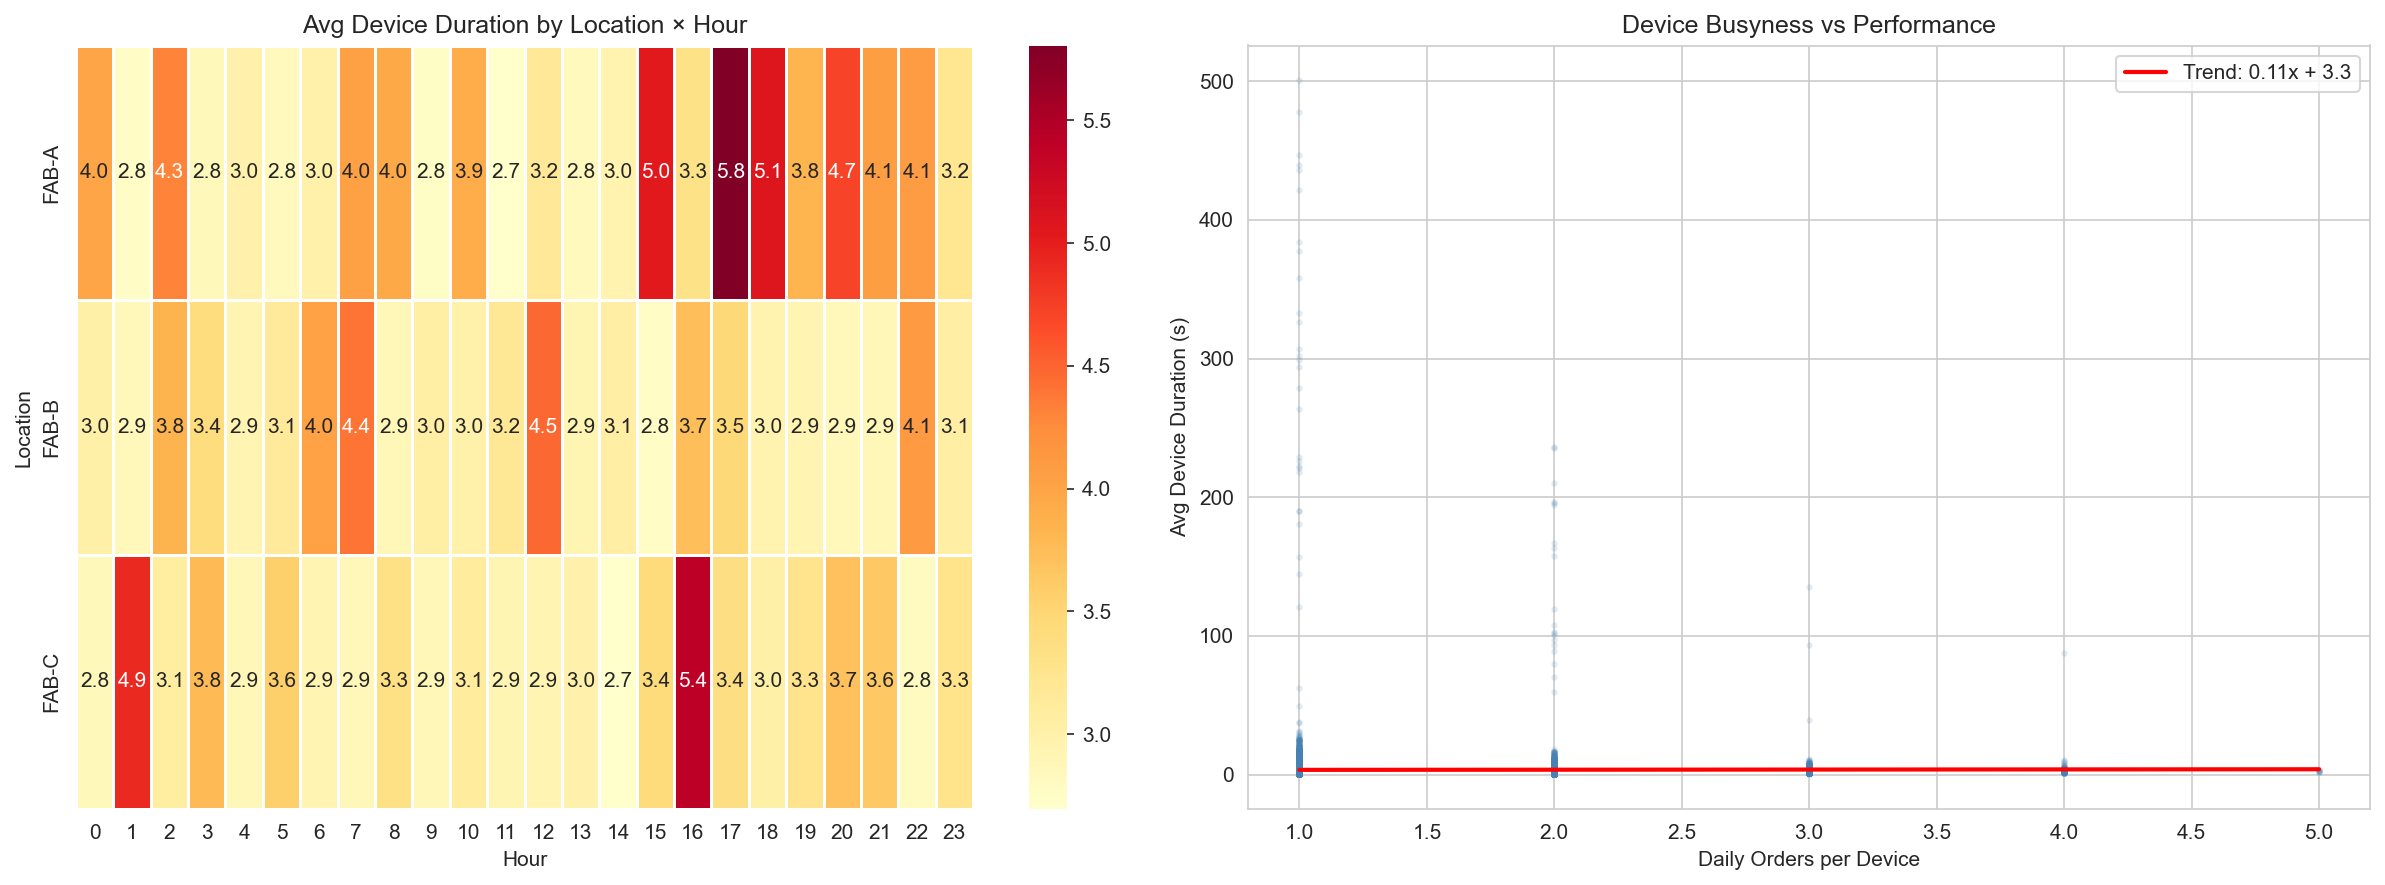

Busyness vs performance correlation: 0.005
  ✓ 無顯著相關 — device 效能不受忙碌度影響


In [9]:
# Device utilization: hour × loc_1 heatmap + busy vs performance scatter
normal['hour'] = normal['order_created_at'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: loc_1 × hour heatmap (avg device_duration)
pivot = normal.groupby(['loc_1', 'hour'])['device_duration_avg_seconds'].mean().unstack(fill_value=0)
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Avg Device Duration by Location × Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Location')

# Right: daily order count per device vs avg device_duration
normal['date'] = normal['order_created_at'].dt.date
dev_daily = normal.groupby(['device_id', 'date']).agg(
    daily_orders=('order_id', 'count'),
    avg_device_dur=('device_duration_avg_seconds', 'mean'),
).reset_index()

axes[1].scatter(dev_daily['daily_orders'], dev_daily['avg_device_dur'], 
                alpha=0.1, s=5, c='steelblue')
axes[1].set_title('Device Busyness vs Performance')
axes[1].set_xlabel('Daily Orders per Device')
axes[1].set_ylabel('Avg Device Duration (s)')

# Trend line
if len(dev_daily) > 10:
    z = np.polyfit(dev_daily['daily_orders'], dev_daily['avg_device_dur'], 1)
    x_line = np.linspace(dev_daily['daily_orders'].min(), dev_daily['daily_orders'].max(), 100)
    axes[1].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2, 
                 label=f'Trend: {z[0]:.2f}x + {z[1]:.1f}')
    axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step4_device_utilization.png', dpi=150)
plt.show()

# Check if busy devices are slower
if len(dev_daily) > 10:
    corr = dev_daily['daily_orders'].corr(dev_daily['avg_device_dur'])
    print(f"Busyness vs performance correlation: {corr:.3f}")
    if abs(corr) > 0.3:
        print(f"  ⚠️ 相關性顯著 — 忙碌的 device 確實比較慢")
    else:
        print(f"  ✓ 無顯著相關 — device 效能不受忙碌度影響")


In [10]:
print(f"=== Step 4 Summary ===")
print(f"Method: {method}")
print(f"Slow devices: {n_slow}")
if n_slow > 0:
    for _, row in slow_devices.iterrows():
        print(f"  {row['device_id']}: median={row['device_dur_median']:.1f}s, "
              f"p95={row['device_dur_p95']:.1f}s, n={row['order_count']}, "
              f"loc={row['loc_1']}/{row.get('loc_2','')}, sys={row['system_name']}")


=== Step 4 Summary ===
Method: fallback: > global P99 (7.8s)
Slow devices: 20
  DEV-0013: median=9.0s, p95=14.7s, n=11, loc=FAB-B/AREA-3, sys=SYS-GAMMA
  DEV-0051: median=8.5s, p95=25.1s, n=14, loc=FAB-A/AREA-2, sys=SYS-GAMMA
  DEV-0061: median=9.0s, p95=13.0s, n=18, loc=FAB-C/AREA-1, sys=SYS-ALPHA
  DEV-0065: median=9.0s, p95=24.6s, n=21, loc=FAB-A/AREA-2, sys=SYS-BETA
  DEV-0228: median=9.4s, p95=15.9s, n=12, loc=FAB-B/AREA-1, sys=SYS-ALPHA
  DEV-0407: median=8.5s, p95=16.6s, n=18, loc=FAB-C/AREA-2, sys=SYS-GAMMA
  DEV-0451: median=10.0s, p95=17.0s, n=16, loc=FAB-B/AREA-3, sys=SYS-ALPHA
  DEV-0476: median=8.3s, p95=14.9s, n=13, loc=FAB-B/AREA-2, sys=SYS-ALPHA
  DEV-0563: median=8.6s, p95=16.1s, n=22, loc=FAB-B/AREA-2, sys=SYS-BETA
  DEV-0569: median=8.8s, p95=11.6s, n=18, loc=FAB-B/None, sys=SYS-GAMMA
  DEV-0864: median=9.5s, p95=11.3s, n=11, loc=FAB-A/AREA-2, sys=SYS-ALPHA
  DEV-1034: median=9.0s, p95=24.7s, n=14, loc=FAB-A/AREA-3, sys=SYS-BETA
  DEV-1232: median=8.3s, p95=18.4s, n=

In [11]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 4 — Slow Device Drilldown")
summary.append("")
summary.append("資料範圍：全部訂單，僅排除 user contention")
summary.append("  （保留 system anomaly orders，避免 slow device 的正常高值被排除後 median 被壓低）")
summary.append("=" * 60)
summary.append(f"\nMethod: {method}")
summary.append(f"  （gap detection: 將 device 按 median 排序，找最大斷層；fallback: > global P99 of device medians）")
summary.append(f"Slow devices: {n_slow}  （被識別為持續性慢的設備數量）")
if n_slow > 0:
    summary.append(f"\nSlow Device List:")
    summary.append(f"  median = 該 device 的 device_duration 中位數（正常 device 通常 2-3s）")
    summary.append(f"  p95 = 該 device 的 device_duration 第 95 百分位")
    summary.append(f"  n = 該 device 的正常訂單數（太少可能是 noise）")
    summary.append("")
    for _, row in slow_devices.iterrows():
        summary.append(f"  {row['device_id']}: median={row['device_dur_median']:.1f}s, "
              f"p95={row['device_dur_p95']:.1f}s, n={row['order_count']}, "
              f"loc={row['loc_1']}/{row.get('loc_2','')}, sys={row['system_name']}")
else:
    summary.append(f"\n所有 device 效能差異不大，無明顯慢機台。")

# High usage + slow = most affected users
summary.append(f"\n--- 使用量 × 效能分析（device = user）---")
summary.append(f"")
summary.append(f"  背景：每台 device 綁定一位 user，device 訂單數 = user 使用頻率。")
summary.append(f"  目的：找出「又常用又慢」的 device → 影響最大的 user，優先修復。")
summary.append(f"")
summary.append(f"  High usage 定義：device 訂單數 ≥ P{HIGH_USAGE_PERCENTILE} = {usage_threshold:.0f} orders（前 {100-HIGH_USAGE_PERCENTILE}% 的 device）")
summary.append(f"  Slow 定義：同上方 gap detection / fallback 的 {n_slow} 台 slow devices")
summary.append(f"")
summary.append(f"  Order count 分佈：")
summary.append(f"    P25={device_perf['order_count'].quantile(0.25):.0f}, "
               f"P50={device_perf['order_count'].median():.0f}, "
               f"P75={device_perf['order_count'].quantile(0.75):.0f}, "
               f"P95={device_perf['order_count'].quantile(0.95):.0f}, "
               f"max={device_perf['order_count'].max()}")
summary.append(f"")

# Cross-analysis summary
summary.append(f"  交叉分析（4 象限）：")
summary.append(f"    {'Usage':<6} {'Speed':<6} {'Devices':>8} {'Orders':>8} {'Median':>8}  Priority")
summary.append(f"    {'-'*6} {'-'*6} {'-'*8} {'-'*8} {'-'*8}  {'-'*10}")
for _, row in cross.iterrows():
    summary.append(f"    {row['usage']:<6} {row['speed']:<6} {row['devices']:>8,} {row['total_orders']:>8,} {row['dur_median']:>7.1f}s  {row['priority']}")

summary.append(f"")
summary.append(f"  解讀：")
summary.append(f"    🔴 Priority = 又常用又慢 → 這些 user 每天都在承受慢速，應優先修復硬體/firmware")
summary.append(f"    🟡 Monitor  = 低使用量但慢 → 影響範圍小，但設備仍有問題，排隊處理")
summary.append(f"    ✅ OK       = 速度正常，無需處理")

# Priority device detail
summary.append(f"")
summary.append(f"  🔴 Priority Device 清單（{len(high_usage_slow)} 台）：")
if len(high_usage_slow) > 0:
    summary.append(f"    {'Device':<12} {'Orders':>7} {'Median':>8} {'P95':>8} {'Location':<12} {'System':<12}")
    summary.append(f"    {'-'*12} {'-'*7} {'-'*8} {'-'*8} {'-'*12} {'-'*12}")
    for _, row in high_usage_slow.sort_values('order_count', ascending=False).iterrows():
        summary.append(f"    {row['device_id']:<12} {row['order_count']:>7} {row['device_dur_median']:>7.1f}s {row['device_dur_p95']:>7.1f}s {row['loc_1']:<12} {row['system_name']:<12}")
else:
    summary.append(f"    （none — slow devices 都是低使用量，影響範圍小）")

with open(str(REPORTS_DIR / 'step4_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step4_summary.txt")


Saved: reports/step4_summary.txt
